
# Baseline Analysis Vs Scenario Analysis


In [1]:
import onstove
print("OnStove is ready!")




OnStove is ready!


In [2]:
#importing all the neccesary packages

import geopandas as gpd
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
from onstove.model import OnStove

from onstove.technology import Technology

## Typical Real Onstove Workflow

#### The real model runs like thus:

##### load configuration ---- Load data --- Run model --- Generate results

In [3]:
# Onstove model runs like thus:

#---Load spatial data
#---Define technologies
#---Set baseline parameters
#--- Modify parameters for scenarios
#--- Run Optimization

In [4]:
# load a raster population
raster = rasterio.open(r"data\ken_pd_2020_1km.tif")

In [5]:
# importing more packages for a more smoth analysis

import os, time
import geopandas as gpd

from onstove import OnStove, DataProcessor, RasterLayer, VectorLayer
from utils import download_data

In [6]:
import utils
print(utils.__file__)

C:\Users\USER\Desktop\OnStove-main\OnStove-main\utils.py


In [7]:
#defining the output directory

output_directory = 'KENYA'

### The below  cell creates your DataProcessor. The DataProcessor will process all raw input GIS datasets and will set the base for your model. OnStove is a raster-based model, hence the spatial resolution of the analysis becomes important. We specify the resolution (cell_size in projection units) when creating the DataProcessor together with the coordinate system (project_crs). This will ensure that all rasters are resampled to the correct resolution and all datasets (vectors and rasters) are reprojected to the target coordinate system.

In [75]:
start = time.time()

data = DataProcessor(project_crs=3395, cell_size=(1000, 1000))
data.output_directory = output_directory

In [9]:
#Importing the administartive boundaries of Kenya

adm_path = r"C:\Users\USER\Desktop\OnStove-main\OnStove-main\data\kenya_admin0.shp"
data.add_mask_layer(category='Administrative', name='Country_boundaries', path=adm_path)

In [10]:
# importing the population of kenya

pop_path = r"C:\Users\USER\Desktop\OnStove-main\OnStove-main\data\ken_pd_2020_1km.tif"
data.add_layer(category='Demographics', name='Population', 
               path=pop_path, layer_type='raster', resample='sum')

#### The cell below creates an OnStove model (calling the OnStove() class) and reads the socio-economic specification file (with country.read_scenario_data(path, delimiter=',')). This file is a csv file that contains the electrification and urban rates and the actual population in the study area (often the GIS datasets of populations have slightly outdated values of population), among other information.

In [11]:
country = OnStove(project_crs=3395)
path = r'C:\Users\USER\Desktop\OnStove-main\OnStove-main\soc_specs.csv'
country.output_directory = output_directory
country.read_scenario_data(path, delimiter=',')

In [12]:
import os

# Use a raw string for Windows paths to avoid unicode errors
population_path = r"C:\Users\USER\Desktop\OnStove-main\OnStove-main\data\ken_pd_2020_1km.tif"

# Optional: check that Python can see the file
if not os.path.exists(population_path):
    raise FileNotFoundError(f"Population raster not found at {population_path}")

# Add the population raster layer to OnStove
country.add_layer(
    category='Demographics',
    name='Population',
    path=population_path,
    layer_type='raster',
    base_layer=True
)

# Optional: convert raster to DataFrame 
country.population_to_dataframe()

In [13]:
print(country.gdf.columns)

Index(['geometry', 'Pop'], dtype='object')


In [14]:
print(country.layers)  # or country.list_layers() if method exists

{'Demographics': {'Population': RasterLayer(name='Population')}}


In [15]:
#This code is a "handshake check" between two different types of spatial data. In geospatial analytics (and specifically when using OnStove), 
#it is a diagnostic step to ensure your Population Map (the raster) and your National Boundary (the vector) are speaking the same "spatial language."

import rasterio
with rasterio.open(population_path) as src:
    print("Raster CRS:", src.crs)

print("GeoDataFrame CRS:", country.gdf.crs)

Raster CRS: EPSG:4326
GeoDataFrame CRS: EPSG:3395


In [57]:
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling

# Input and output paths
input_raster = r"C:\Users\USER\Desktop\OnStove-main\OnStove-main\data\ken_pd_2020_1km.tif"
reproj_raster = r"C:\Users\USER\Desktop\OnStove-main\OnStove-main\data\Population_reproj.tif"

# Reproject raster to match GeoDataFrame CRS
dst_crs = country.gdf.crs  # EPSG:3395

with rasterio.open(input_raster) as src:
    transform, width, height = calculate_default_transform(
        src.crs, dst_crs, src.width, src.height, *src.bounds)
    kwargs = src.meta.copy()
    kwargs.update({
        'crs': dst_crs,
        'transform': transform,
        'width': width,
        'height': height
    })

    with rasterio.open(reproj_raster, 'w', **kwargs) as dst:
        for i in range(1, src.count + 1):
            reproject(
                source=rasterio.band(src, i),
                destination=rasterio.band(dst, i),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=transform,
                dst_crs=dst_crs,
                resampling=Resampling.nearest
            )

In [17]:
country.add_layer(
    category='Demographics',
    name='Population',
    path=reproj_raster,
    layer_type='raster',
    base_layer=True
)

In [23]:
# --- File paths ---
population_raster = "data\ken_pd_2020_1km.tif"
admin_shp = "data\kenya_admin0.shp"
energy_costs = "data/tech_data.csv"


# --- Load the shapefile ---
admin = gpd.read_file(admin_shp)
print("✅ Admin boundaries loaded!")
print(admin.head())

# --- Load the population raster ---
raster = rasterio.open(population_raster)
print("✅ Population raster loaded!")
print("Raster CRS:", raster.crs)
print("Raster bounds:", raster.bounds)

# --- Load energy costs ---
energy = pd.read_csv(energy_costs)
print("✅ Energy costs loaded!")
print(energy)

✅ Admin boundaries loaded!
   Shape_Leng  Shape_Area ADM0_EN ADM0_PCODE ADM0_REF ADM0ALT1EN ADM0ALT2EN  \
0   44.052413   48.098756   Kenya         KE     None       None       None   

        date    validOn validTo  \
0 2017-11-03 2018-06-07     NaT   

                                            geometry  
0  MULTIPOLYGON (((39.22308 -4.66901, 39.22034 -4...  
✅ Population raster loaded!
Raster CRS: EPSG:4326
Raster bounds: BoundingBox(left=33.9070832014676, bottom=-4.725416440136145, right=41.8820831695676, top=5.466250185763855)
✅ Energy costs loaded!
        Fuel       Param  Value data_type
0       wood       share  54.00       int
1        lpg       share  26.00       int
2   charcoal       share   7.00       int
3   electric       share   0.37     float
4       wood   fuel_cost   2.00     float
5        lpg   fuel_cost   5.00     float
6   charcoal   fuel_cost   3.00     float
7   electric   fuel_cost   3.00     float
8       wood  efficiency   0.15     float
9        lpg  ef

TypeError: text() missing 1 required positional argument: 's'

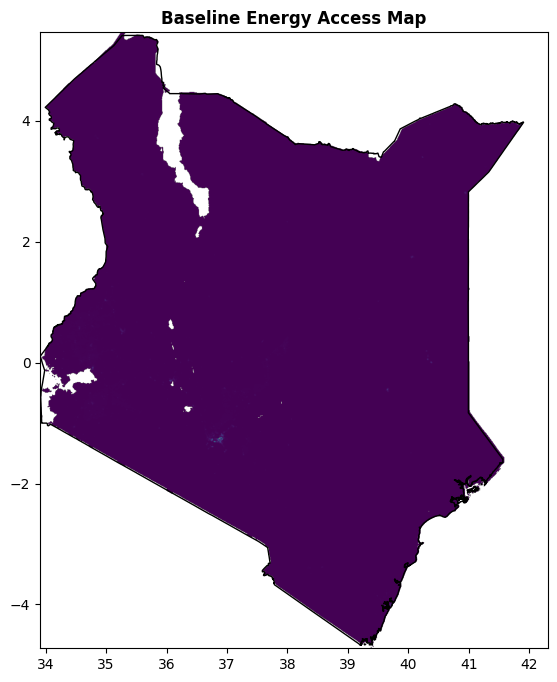

In [59]:
fig, ax = plt.subplots(figsize=(8, 8))

# Plot raster (population density)
show(raster, ax=ax, title="Baseline Energy Access Map")

# Overlay admin boundaries
admin.boundary.plot(ax=ax, color="black", linewidth=1)

# Title annotation
plt.text(
    x=admin.total_bounds[0] + 0.5,
    y=admin.total_bounds[3] - 0.5,
    fontsize=12,
    color="red"
)

plt.show()

### Read the cooking technologies data. The techno-economic specification file is read. This file does two things: 1) it determines the available fuel/stove combinations used in the analysis and 2) it indicates different techno-economic parameters related to these stoves. If a stove is to be added to the analysis the first step is to add it in this file.

In [24]:
path = r'C:\Users\USER\Desktop\OnStove-main\OnStove-main\tech_specs.csv'
country.read_tech_data(path, delimiter=',')

In [60]:
# load your data
tech = pd.read_csv(r'C:\Users\USER\Desktop\OnStove-main\OnStove-main\tech_specs.csv')
soc = pd.read_csv(r'C:\Users\USER\Desktop\OnStove-main\OnStove-main\soc_specs.csv')

print(tech.head())
print(soc.head())

     Fuel               Param   Value data_type   Unit
0  Biogas                pm25      43     float    NaN
1  Biogas      energy_content    22.8     float    NaN
2  Biogas        oc_intensity  0.0091     float  kg/GJ
3  Biogas  time_of_collection       3     float    NaN
4  Biogas     time_of_cooking       2     float    NaN
                   Param     Value data_type
0           Country_name     Kenya    string
1           Country_code       KEN    string
2             Start_year      2020       int
3               End_year      2020       int
4  Population_start_year  53771000       int


In [61]:
# convert social specs to dictionary
soc_dict = dict(zip(soc["Param"], soc["Value"]))

# convert population to number
population = float(soc_dict["Population_start_year"])

print("Population:", population)

Population: 53771000.0


In [62]:
# Define Baseline Cooking Situation

baseline = {
    "wood": 0.80,
    "charcoal": 0.10,
    "lpg": 0.05,
    "electric": 0.05
}

In [76]:
# Onstove always calcualte impact per household

household_size = 3.9
households = population / household_size

print("Total households:", households)

Total households: 13787435.897435898


In [77]:

# Calculating  Baseline Users

baseline_users = {}

for fuel, share in baseline.items():
    baseline_users[fuel] = households * share

print(baseline_users)

{'wood': 11029948.71794872, 'charcoal': 1378743.58974359, 'lpg': 689371.794871795, 'electric': 689371.794871795}


In [78]:

# We get fuel cost or emission from the tech_specs datasets

energy_content = tech[tech["Param"] == "energy_content"]

energy_dict = dict(zip(energy_content["Fuel"], energy_content["Value"]))

print(energy_dict)

{'Biogas': '22.8', 'Biomass Forced Draft': '16', 'Charcoal ICS': '30', 'Collected_Improved_Biomass': '16', 'Collected_Traditional_Biomass': '16', 'Electricity': '3.6', 'Kerosene': '43', 'LPG': '45.5', 'Pellets Forced Draft': '16', 'Traditional_Charcoal': '30'}


In [80]:
# Define Scenario (Policy Change)
# ----Example: electrification push. This simulate: less wood and more electricity

scenario = {
    "wood": 0.20,
    "charcoal": 0.10,
    "lpg": 0.20,
    "electric": 0.50
}

In [81]:
# Calculating Scenario Users

scenario_users = {}

for fuel, share in scenario.items():
    scenario_users[fuel] = households * share

print(scenario_users)

{'wood': 2757487.17948718, 'charcoal': 1378743.58974359, 'lpg': 2757487.17948718, 'electric': 6893717.948717949}


In [82]:
# Comparing Baseline vs Scenario
# Now you know: how many households switch, scale of change. That is part of the core onstove logic

impact = {}

for fuel in baseline.keys():
    impact[fuel] = scenario_users[fuel] - baseline_users[fuel]

print("Change in households:")
print(impact)

Change in households:
{'wood': -8272461.53846154, 'charcoal': 0.0, 'lpg': 2068115.384615385, 'electric': 6204346.153846154}


In [83]:
# Defining all outlined scenarios

scenarios = {
    "baseline": {
        "wood": 0.70,
        "charcoal": 0.10,
        "lpg": 0.05,
        "electric": 0.05
    },

    "green_transition": {
        "wood": 0.30,
        "charcoal": 0.10,
        "lpg": 0.60,
        "electric": 0.50
    },

    "business_as_usual": {
        "wood": 0.75,
        "charcoal": 0.12,
        "lpg": 0.08,
        "electric": 0.05
    },

    "electrification_push": {
        "wood": 0.30,
        "charcoal": 0.10,
        "lpg": 0.10,
        "electric": 0.50
    }
}

In [84]:
# Calculate users for every scenario automatically

# --- Now we have: baseline users, green transition users, BAU users, electrification users.

scenario_results = {}

for scenario_name, shares in scenarios.items():
    
    users = {}
    
    for fuel, share in shares.items():
        users[fuel] = households * share
    
    scenario_results[scenario_name] = users

print(scenario_results)


{'baseline': {'wood': 9651205.128205128, 'charcoal': 1378743.58974359, 'lpg': 689371.794871795, 'electric': 689371.794871795}, 'green_transition': {'wood': 4136230.769230769, 'charcoal': 1378743.58974359, 'lpg': 8272461.538461538, 'electric': 6893717.948717949}, 'business_as_usual': {'wood': 10340576.923076924, 'charcoal': 1654492.3076923077, 'lpg': 1102994.8717948718, 'electric': 689371.794871795}, 'electrification_push': {'wood': 4136230.769230769, 'charcoal': 1378743.58974359, 'lpg': 1378743.58974359, 'electric': 6893717.948717949}}


In [72]:
# for the sake of impact; the goal mostly is to achieve electrification.
# So we compare electrification vs baseline.

baseline_users = scenario_results["baseline"]
electric_push_users = scenario_results["electrification_push"]

impact = {}

for fuel in baseline_users:
    impact[fuel] = electric_push_users[fuel] - baseline_users[fuel]

print("Impact vs baseline:")
print(impact)

Impact vs baseline:
{'wood': -4301679.999999999, 'charcoal': 0.0, 'lpg': 537710.0, 'electric': 4839390.0}


In [73]:


# ---------------------------------------------------
# 1. LOAD DATA
# ---------------------------------------------------

tech = pd.read_csv(r'C:\Users\USER\Desktop\OnStove-main\OnStove-main\tech_specs.csv')
soc = pd.read_csv(r'C:\Users\USER\Desktop\OnStove-main\OnStove-main\soc_specs.csv')

soc_dict = dict(zip(soc["Param"], soc["Value"]))

# clean numeric values
population = float(str(soc_dict["Population_start_year"]).replace(",", ""))
income = float(str(soc_dict.get("Income", 5000)).replace(",", ""))  # fallback if missing

household_size = 5
households = population / household_size

print("\nPopulation:", population)
print("Households:", households)


# 2. BASELINE COOKING (CURRENT REALITY)


baseline = {
    "wood": 0.80,
    "charcoal": 0.10,
    "lpg": 0.05,
    "electric": 0.05
}

baseline_users = {
    fuel: households * share
    for fuel, share in baseline.items()
}


# 3. SCENARIOS (FUTURE CONDITIONS)


scenarios = {
    "baseline": baseline,

    "green_transition": {
        "wood": 0.40,
        "charcoal": 0.10,
        "lpg": 0.20,
        "electric": 0.30
    },

    "business_as_usual": {
        "wood": 0.75,
        "charcoal": 0.12,
        "lpg": 0.08,
        "electric": 0.05
    },

    "electrification_push": {
        "wood": 0.30,
        "charcoal": 0.10,
        "lpg": 0.10,
        "electric": 0.50
    }
}


# 4. ENERGY STACKING BEHAVIOUR

stacking_rules = {
    "wood": {"wood": 0.6, "electric": 0.4},
    "lpg": {"lpg": 0.8, "electric": 0.2},
    "electric": {"electric": 1.0},
    "charcoal": {"charcoal": 1.0}
}

def apply_stacking(users, rules):
    final = {}

    for fuel, count in users.items():
        for newfuel, share in rules[fuel].items():
            final[newfuel] = final.get(newfuel, 0) + count * share

    return final


# 5. ADOPTION SPEED (TRANSITION OVER YEARS)


def simulate_transition(start_users, years=10, rate=0.08):
    users = start_users.copy()
    history = []

    for year in range(years):
        switch = users["wood"] * rate
        users["wood"] -= switch
        users["electric"] += switch
        history.append(users.copy())

    return history


# 6. FUEL COST EXTRACTION


fuel_cost = tech[tech["Param"] == "fuel_cost"]

cost_dict = dict(zip(
    fuel_cost["Fuel"].str.lower(),
    fuel_cost["Value"]
))

def total_cost(users, cost_dict):
    total = 0

    for fuel, count in users.items():
        if fuel in cost_dict:
            total += count * float(cost_dict[fuel])

    return total


# 7. AFFORDABILITY MODEL


def is_affordable(cost, households, income):
    cost_per_household = cost / households
    return cost_per_household <= 0.1 * income


# 8. RUN ALL SCENARIOS


results = {}

for scenario_name, shares in scenarios.items():

    print("\n--- Running:", scenario_name, "---")

    # calculate users
    users = {
        fuel: households * share
        for fuel, share in shares.items()
    }

    # apply stacking behaviour
    stacked_use = apply_stacking(users, stacking_rules)

    # simulate adoption pathway
    transition_path = simulate_transition(users)

    # calculate cost
    cost = total_cost(stacked_use, cost_dict)

    # affordability
    affordable = is_affordable(cost, households, income)

    results[scenario_name] = {
        "users": users,
        "stacked": stacked_use,
        "cost": cost,
        "affordable": affordable,
        "transition": transition_path
    }

    print("Total cost:", cost)
    print("Affordable:", affordable)


# 9. IMPACT VS BASELINE


baseline_users = results["baseline"]["users"]

print("\n=== IMPACT VS BASELINE ===")

for name, data in results.items():

    if name == "baseline":
        continue

    print("\nScenario:", name)

    for fuel in baseline_users:
        change = data["users"][fuel] - baseline_users[fuel]
        print(fuel, "change:", change)

# ---------------------------------------------------

print("\n=== MODEL COMPLETE ===")


Population: 53771000.0
Households: 10754200.0

--- Running: baseline ---
Total cost: 705475.5199999999
Affordable: True

--- Running: green_transition ---
Total cost: 2821902.0799999996
Affordable: True

--- Running: business_as_usual ---
Total cost: 1128760.832
Affordable: True

--- Running: electrification_push ---
Total cost: 1410951.0399999998
Affordable: True

=== IMPACT VS BASELINE ===

Scenario: green_transition
wood change: -4301680.0
charcoal change: 0.0
lpg change: 1613130.0
electric change: 2688550.0

Scenario: business_as_usual
wood change: -537710.0
charcoal change: 215084.0
lpg change: 322626.0
electric change: 0.0

Scenario: electrification_push
wood change: -5377100.0
charcoal change: 0.0
lpg change: 537710.0
electric change: 4839390.0

=== MODEL COMPLETE ===


## Visualizing the national dataset, mapping the areas with the potential of high adopton rate

In [85]:
# create the raster friendly environment mapped by total admin boundary.

model = OnStove(
    project_crs=3395,     
    cell_size=(1000, 1000),
    output_directory="KENYA"
)

In [86]:
model.add_layer(
    "data/kenya_admin0.shp",  
    layer_type="vector",
    category="base",
    name="admin"
)

In [87]:
model.add_layer(
    "data\ken_pd_2020_1km.tif",
    layer_type="raster",
    category="demand",
    name="population"
)

In [74]:
with rasterio.open(population_path) as src:
    print("Raster CRS:", src.crs)

print("GeoDataFrame CRS:", country.gdf.crs)

Raster CRS: EPSG:4326
GeoDataFrame CRS: EPSG:3395


In [56]:
model.read_tech_data("tech_specs.csv")
model.read_social_data("soc_specs.csv.xlsx")

model.set_base_fuel("wood")

model.calibrate_current_pop()
model.calibrate_urban_rural_split()

model.run()
model.summary()

UnicodeDecodeError: 'charmap' codec can't decode byte 0x9d in position 16: character maps to <undefined>

### Visualization of the analysis conducted

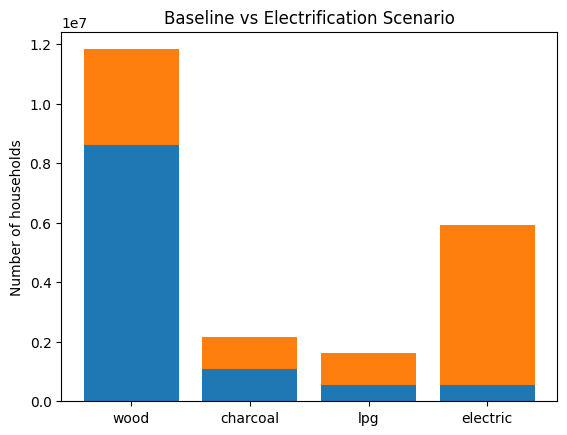

In [36]:


fuels = list(baseline_users.keys())

baseline_values = [baseline_users[f] for f in fuels]
scenario_values = [results["electrification_push"]["users"][f] for f in fuels]

x = range(len(fuels))

plt.figure()
plt.bar(x, baseline_values)
plt.bar(x, scenario_values, bottom=baseline_values)

plt.xticks(x, fuels)
plt.title("Baseline vs Electrification Scenario")
plt.ylabel("Number of households")
plt.show()

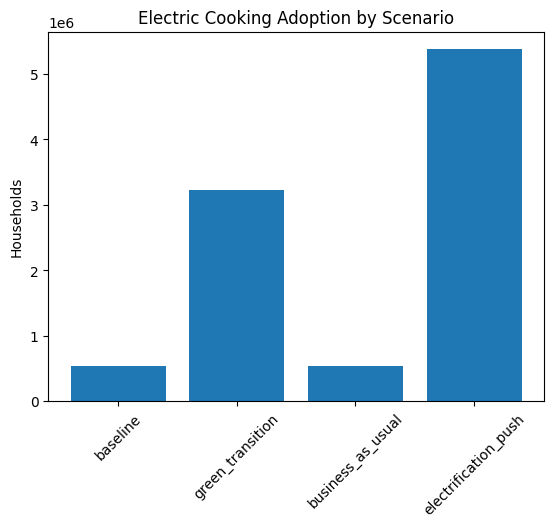

In [37]:
# Scenario Comparison Chart (compare electric adoption)



scenario_names = []
electric_values = []

for name, data in results.items():
    scenario_names.append(name)
    electric_values.append(data["users"]["electric"])

plt.figure()
plt.bar(scenario_names, electric_values)

plt.title("Electric Cooking Adoption by Scenario")
plt.ylabel("Households")
plt.xticks(rotation=45)
plt.show()

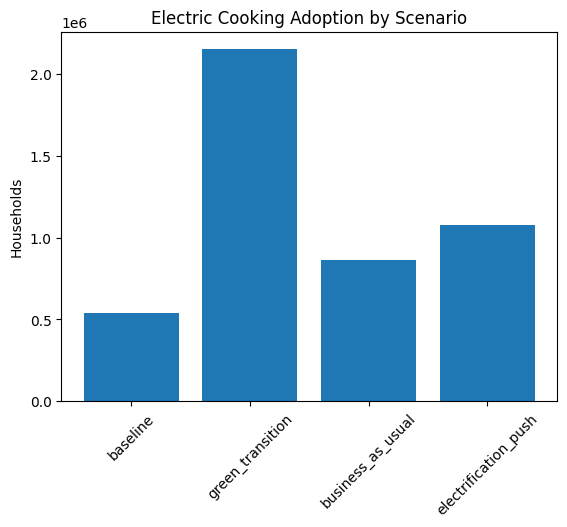

In [39]:
# Scenario Comparison Chart (compare lpg adoption)


scenario_names = []
electric_values = []

for name, data in results.items():
    scenario_names.append(name)
    electric_values.append(data["users"]["lpg"])

plt.figure()
plt.bar(scenario_names, electric_values)

plt.title("Electric Cooking Adoption by Scenario")
plt.ylabel("Households")
plt.xticks(rotation=45)
plt.show()

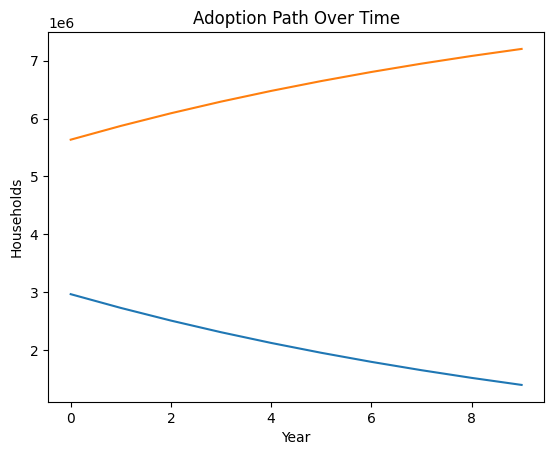

In [50]:
transition = results["electrification_push"]["transition"]

wood = [year["wood"] for year in transition]
electric = [year["electric"] for year in transition]

plt.figure()
plt.plot(wood)
plt.plot(electric)


plt.title("Adoption Path Over Time")
plt.xlabel("Year")
plt.ylabel("Households")
plt.show()

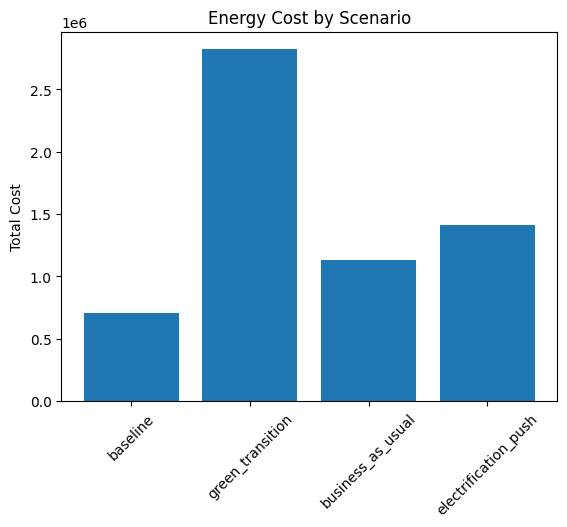

In [44]:
scenario_costs = {name: data["cost"] for name, data in results.items()}

plt.figure()
plt.bar(scenario_costs.keys(), scenario_costs.values())

plt.title("Energy Cost by Scenario")
plt.ylabel("Total Cost")
plt.xticks(rotation=45)
plt.show()

### Adotpion in the next five years

In [45]:
adoption_rates = {
    "wood_to_electric": 0.08,   # 8% per year
    "wood_to_lpg": 0.03         # 3% per year
}

In [46]:
def project_adoption(start_users, years=5):

    users = start_users.copy()
    history = []

    for year in range(years):

        wood = users["wood"]

        # households switching
        to_electric = wood * 0.08
        to_lpg = wood * 0.03

        # update counts
        users["wood"] -= (to_electric + to_lpg)
        users["electric"] += to_electric
        users["lpg"] += to_lpg

        history.append(users.copy())

    return history

In [47]:
five_year_projection = project_adoption(baseline_users, years=5)

for i, year in enumerate(five_year_projection):
    print("Year", i+1, year)

Year 1 {'wood': 7656990.4, 'charcoal': 1075420.0, 'lpg': 795810.8, 'electric': 1225978.8}
Year 2 {'wood': 6814721.456, 'charcoal': 1075420.0, 'lpg': 1025520.5120000001, 'electric': 1838538.0320000001}
Year 3 {'wood': 6065102.095840001, 'charcoal': 1075420.0, 'lpg': 1229962.15568, 'electric': 2383715.74848}
Year 4 {'wood': 5397940.865297601, 'charcoal': 1075420.0, 'lpg': 1411915.2185552001, 'electric': 2868923.9161472}
Year 5 {'wood': 4804167.370114865, 'charcoal': 1075420.0, 'lpg': 1573853.4445141281, 'electric': 3300759.185371008}


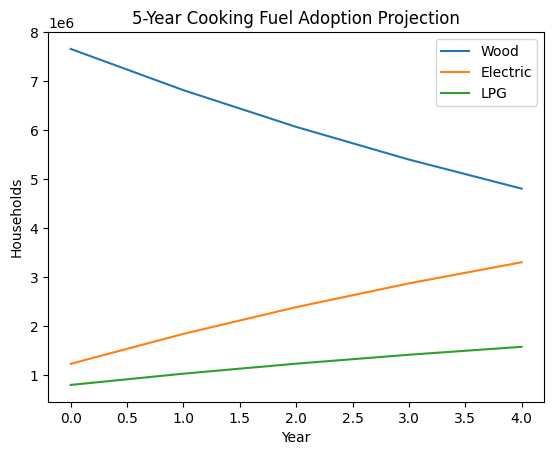

In [48]:


wood = [y["wood"] for y in five_year_projection]
electric = [y["electric"] for y in five_year_projection]
lpg = [y["lpg"] for y in five_year_projection]

plt.figure()
plt.plot(wood, label="Wood")
plt.plot(electric, label="Electric")
plt.plot(lpg, label="LPG")

plt.legend()
plt.title("5-Year Cooking Fuel Adoption Projection")
plt.xlabel("Year")
plt.ylabel("Households")
plt.show()